# Playground

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely import geometry, set_precision
import shapely
from shapely.geometry.linestring import LineString
from shapely.ops import unary_union, split
import networkx as nx
import osmnx as ox
import momepy
import matplotlib.pyplot as plt
import contextily as cx
import copy

In [2]:
def plot_maps(*maps):
    fig, ax = plt.subplots()
    for map, color in maps:
        map.plot(ax=ax, color=color)
    cx.add_basemap(ax=ax, crs=gdf_shape.crs, source=cx.providers.CartoDB.Positron)
    plt.show()

## Validate CRS function

In [3]:
def validate_crs(gdf):
    if gdf.crs.is_geographic:
        gdf = gdf.to_crs(epsg=4326)
        return gdf.to_crs(gdf.estimate_utm_crs())
    return gdf

## Centroid function

In [4]:
def get_centroids(gdf):
    gdf = validate_crs(gdf)
    gdf['shape_centroid'] = gdf.geometry.centroid
    return gdf

In [5]:
gdf_shape = gpd.read_file('test_shapes.gpkg')
get_centroids(gdf_shape)

,id,feat,geometry,shape_centroid
0,1,first,"MULTIPOLYGON (((322109.431 4730357.405, 322255...",POINT (321816.211 4730103.326)
1,2,second,"MULTIPOLYGON (((322535.551 4730198.913, 322504...",POINT (322622.382 4730293.955)
2,3,third,"MULTIPOLYGON (((322285.486 4729706.411, 322224...",POINT (322362.492 4729893.569)


## Segment function

In [6]:
def segment_lines(gdf_polylines):
    gdf_polylines = validate_crs(gdf_polylines)

    segmented_lines = unary_union(gdf_polylines.geometry)
    segmented_lines = shapely.get_parts(segmented_lines)
    segments = []
    for line in segmented_lines:
        coords = list(line.coords)
        for i in range(len(coords) - 1):
            segments.append(shapely.geometry.LineString([coords[i], coords[i + 1]]))

    return gpd.GeoDataFrame(geometry=segments, crs=gdf_polylines.crs)

In [21]:
gdf_lines = gpd.read_file('test_lines2.gpkg')
type(segment_lines(gdf_lines).geometry.loc[23])

shapely.geometry.linestring.LineString

## Snap targets to route function



In [56]:
def snap_points_to_route(gdf_polylines, gdf):
    gdf_polylines = validate_crs(gdf_polylines)
    gdf = validate_crs(gdf)

    gdf_snapped = gpd.sjoin_nearest(get_centroids(gdf), gdf_polylines, how='left')[['shape_centroid', 'index_right']].drop_duplicates(subset='shape_centroid')
    gdf_snapped = gdf_snapped.merge(gdf_polylines[['geometry']], left_on='index_right', right_index=True)
    gdf_snapped['start_line'] = gdf_snapped['geometry'].interpolate(gdf_snapped['geometry'].project(gdf_snapped['shape_centroid']))
    new_rows = []
    for row in gdf_snapped.iloc:
        new_rows.append({'geometry': LineString([row['start_line'], row['shape_centroid']])})
    new_gdf = gpd.GeoDataFrame(new_rows, crs=gdf_polylines.crs)
    return pd.concat([gdf_polylines, new_gdf], ignore_index=True)
    # return gdf_snapped

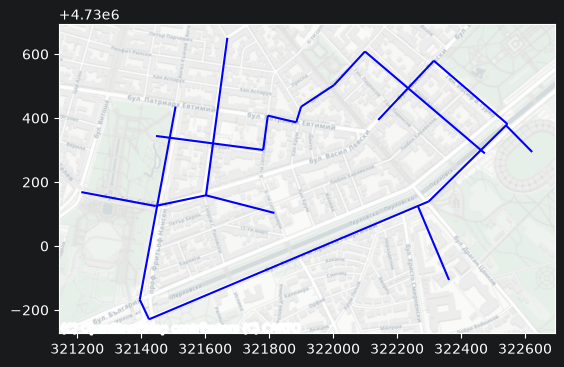

In [58]:
snapped_targets = snap_points_to_route(segment_lines(gdf_lines), get_centroids(gdf_shape))
# snapped_targets
plot_maps((snapped_targets, 'blue'))

In [59]:
# Start Here

## Segment line with snapped points function

In [ ]:
def add_to_route(gdf_polylines, gdf_snapped):
    gdf_snapped = validate_crs(gdf_snapped)
    gdf_polylines = validate_crs(gdf_polylines)
    new_rows = []
    for row in gdf_snapped.iloc:
        new_rows.append({'geometry': LineString([row['snapped_centroid'], row['centroid']])})
    new_gdf = gpd.GeoDataFrame(new_rows, crs=gdf_polylines.crs)
    return pd.concat([gdf_polylines, new_gdf], ignore_index=True)

In [ ]:
add_to_route(gdf_lines, snap_points_to_route(get_centroids(gdf_shape), segment_lines(gdf_lines))).crs

In [ ]:
lines = gpd.read_file('test_lines2.gpkg')
shape = gpd.read_file('test_shapes.gpkg')

centroids = get_centroids(shape)
route = segment_lines(lines)
snapped = snap_points_to_route(centroids, route)
added = add_to_route(route, snapped)
route = segment_lines(added)

plot_maps((route, 'purple'), (centroids['centroid'], 'green'), (snapped['snapped_centroid'], 'blue'))

## Create isochrones function

In [ ]:
def create_isochrones(route: gpd.GeoDataFrame | nx.Graph, starting_point: shapely.geometry.Point):
    if type(route) == gpd.GeoDataFrame:
        route = momepy.gdf_to_nx(route, approach='primal', length='length')
    # isochrone = nx.ego_graph(route, starting_point)
    return route

In [ ]:
G = create_isochrones(segment_lines(gdf_lines), get_centroids(gdf_shape).iloc[0])
nx.draw(G, {x: [x[0], x[1]] for x in list(G.nodes)}, node_size=8)
plt.show()